<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/NB6_Sesion2_Tarea_Optimizacion_Costos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 4 · Estadística Aplicada y Confiabilidad de Activos
## Sesión 2 — Confiabilidad de activos y simulación de fallas

Programa de Certificación en Ciencia de Datos aplicada al Mantenimiento Predictivo

### Notebook 6 · Tarea — Intervalo óptimo de mantenimiento preventivo por costo

**Nivel:** esta tarea requiere una decisión de optimización que un LLM no resuelve por ti de forma directa: debes construir y correr una simulación de costos y **elegir un intervalo** con base en los resultados, no solo generar código. Un asistente de IA puede ayudarte con sintaxis puntual, pero el diseño del experimento y la interpretación final son tuyos.

**Entrega:** notebook ejecutado + una celda final de recomendación (mínimo 150 palabras) dirigida al gerente de mantenimiento de la planta.

## Contexto

Para el **Ventilador Industrial**, la planta paga:

- **Costo de mantenimiento preventivo (planeado):** \$3,500 MXN por intervención
- **Costo de una falla no planeada:** \$18,000 MXN (paro de línea + reparación de emergencia)

Tu tarea es encontrar, mediante simulación Montecarlo, el **intervalo de mantenimiento preventivo (en horas)** que minimiza el costo total esperado por hora de operación.

## Análisis de Confiabilidad R(t)

Antes de pasar a la simulación de costos, es útil entender la función de confiabilidad $R(t)$ del ventilador industrial, que representa la probabilidad de que el equipo siga operando sin fallas después de un tiempo $t$. También identificaremos el tiempo en el que la confiabilidad es del 50%.

In [23]:
import numpy as np
import pandas as pd
from scipy import stats

EQUIPOS = {
    "Bomba Centrífuga":       {"beta": 2.8, "eta": 850,  "n_fallas": 60},
    "Motor Eléctrico":        {"beta": 1.0, "eta": 1200, "n_fallas": 55},
    "Compresor de Aire":      {"beta": 0.6, "eta": 400,  "n_fallas": 70},
    "Ventilador Industrial":  {"beta": 2.2, "eta": 1000, "n_fallas": 50},
    "Transportador de Banda": {"beta": 1.1, "eta": 900,  "n_fallas": 58},
}

def generar_tbf(equipo, params, seed):
    rng = np.random.default_rng(seed)
    tbf = rng.weibull(params["beta"], params["n_fallas"]) * params["eta"]
    return pd.DataFrame({"equipo": equipo, "tbf_horas": tbf})

fallas = pd.concat(
    [generar_tbf(eq, p, seed=i + 30) for i, (eq, p) in enumerate(EQUIPOS.items())],
    ignore_index=True,
)
fallas.head()

,equipo,tbf_horas
0,Bomba Centrífuga,768.129588
1,Bomba Centrífuga,464.647536
2,Bomba Centrífuga,602.903346
3,Bomba Centrífuga,585.879966
4,Bomba Centrífuga,1274.825088


In [24]:
ventilador = fallas[fallas["equipo"] == "Ventilador Industrial"]["tbf_horas"].values

beta, loc, eta = stats.weibull_min.fit(ventilador, floc=0)
print(f"β = {beta:.2f}, η = {eta:.1f} h")

β = 1.96, η = 982.7 h


### Contexto: ¿cómo se compara el Ventilador contra el resto de la flota?

Igual que en el Notebook 4, antes de optimizar, vale la pena ver la tabla de β, η, MTBF y B10 de los 5 equipos — te ayuda a juzgar si el intervalo que vas a recomendar para el Ventilador tiene sentido frente a equipos similares.

In [25]:
resumen = []
for equipo in EQUIPOS:
    datos = fallas[fallas["equipo"] == equipo]["tbf_horas"].values
    b, l, e = stats.weibull_min.fit(datos, floc=0)
    resumen.append({
        "equipo": equipo,
        "beta": b,
        "eta": e,
        "MTBF_h": stats.weibull_min.mean(b, loc=0, scale=e),
        "B10_h": stats.weibull_min.ppf(0.10, b, loc=0, scale=e),
    })

pd.DataFrame(resumen).sort_values("beta", ascending=False).round(1)

,equipo,beta,eta,MTBF_h,B10_h
0,Bomba Centrífuga,3.0,860.4,768.3,406.0
3,Ventilador Industrial,2.0,982.7,871.2,311.4
4,Transportador de Banda,1.2,935.5,877.3,146.7
1,Motor Eléctrico,1.0,998.2,1018.2,95.0
2,Compresor de Aire,0.6,468.2,662.4,13.2


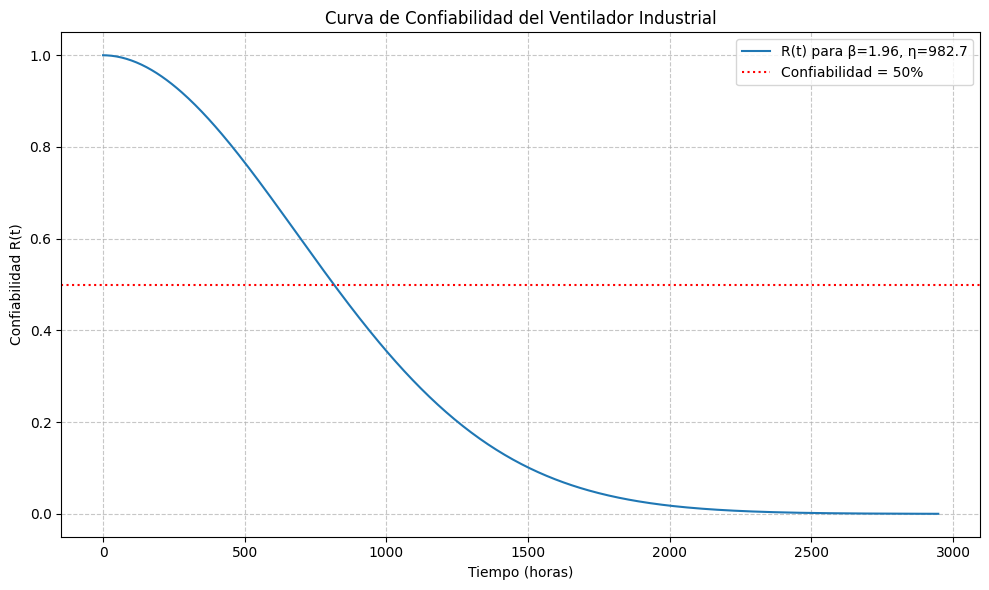

In [26]:
from scipy.stats import weibull_min
import matplotlib.pyplot as plt

# Los parámetros beta_ventilador y eta_ventilador ya están definidos en celdas anteriores

# Definir la función de confiabilidad R(t) para la distribución Weibull
def confiabilidad_weibull(t, beta, eta):
    return weibull_min.sf(t, beta, loc=0, scale=eta)

# Crear un rango de tiempo para graficar
t_valores = np.linspace(0, 3 * eta_ventilador, 500) # Hasta 3 veces eta para ver el comportamiento

# Calcular los valores de confiabilidad para cada t
r_valores = [confiabilidad_weibull(t, beta_ventilador, eta_ventilador) for t in t_valores]

# Graficar la curva de confiabilidad
plt.figure(figsize=(10, 6))
plt.plot(t_valores, r_valores, label=f'R(t) para β={beta_ventilador:.2f}, η={eta_ventilador:.1f}')
plt.title('Curva de Confiabilidad del Ventilador Industrial')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Confiabilidad R(t)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0.5, color='r', linestyle=':', label='Confiabilidad = 50%')
plt.legend()
plt.tight_layout()
plt.show()

El tiempo en el que la confiabilidad es del 50% es: 814.94 horas


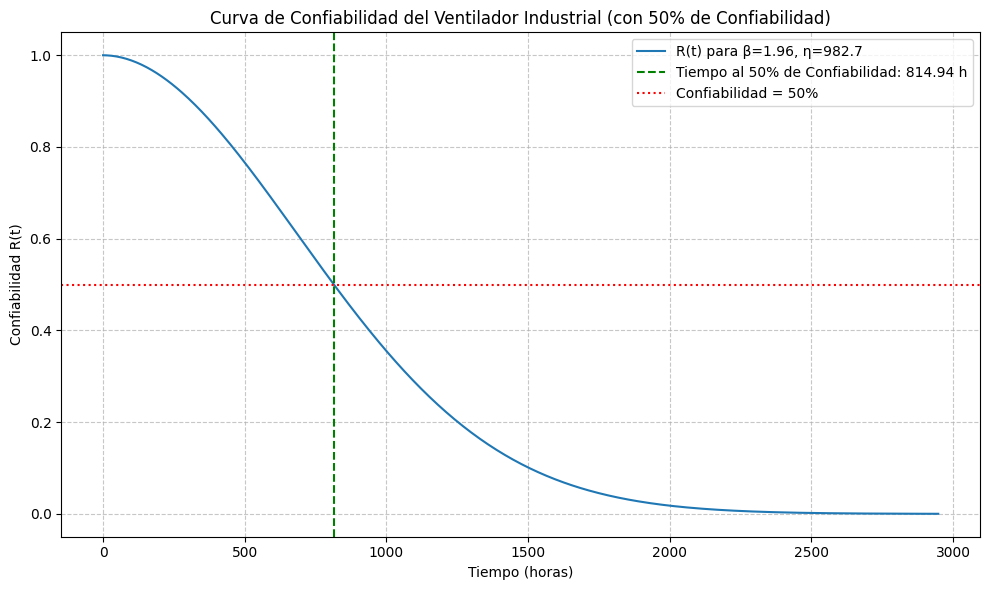

In [27]:
# Encontrar el tiempo en el que la confiabilidad es del 50%

# La función percentil point function (ppf) es la inversa de la CDF.
# Para F(t) = 0.5, queremos el tiempo t. Y sabemos que R(t) = 1 - F(t)
# Entonces, R(t) = 0.5 implica F(t) = 0.5
t_50_confiabilidad = weibull_min.ppf(0.5, beta_ventilador, loc=0, scale=eta_ventilador)

print(f"El tiempo en el que la confiabilidad es del 50% es: {t_50_confiabilidad:.2f} horas")

# Añadir el punto al gráfico si no se hizo antes en la celda anterior
# Ya se añadió una línea horizontal en 0.5, ahora añadimos un punto vertical para t_50_confiabilidad
plt.figure(figsize=(10, 6))
plt.plot(t_valores, r_valores, label=f'R(t) para β={beta_ventilador:.2f}, η={eta_ventilador:.1f}')
plt.axvline(x=t_50_confiabilidad, color='g', linestyle='--', label=f'Tiempo al 50% de Confiabilidad: {t_50_confiabilidad:.2f} h')
plt.axhline(y=0.5, color='r', linestyle=':', label='Confiabilidad = 50%')
plt.title('Curva de Confiabilidad del Ventilador Industrial (con 50% de Confiabilidad)')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Confiabilidad R(t)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## Parte 1 — Simular el ciclo de vida del equipo

Para un intervalo de mantenimiento preventivo `T` dado, simula 5,000 "vidas" del equipo usando los parámetros de Weibull ajustados. Para cada vida simulada:

- Si el tiempo de falla simulado es **menor** que `T`: ocurre una falla no planeada (cuesta \$18,000).
- Si el tiempo de falla simulado es **mayor o igual** que `T`: se reemplaza preventivamente en `T` (cuesta \$3,500).

Calcula el **costo esperado por hora de operación** para ese `T` (costo total / horas totales operadas).

In [13]:
def costo_por_hora(T, beta, eta, n_sim=10000, seed=0, costo_prev=3500, costo_falla=18000):
    rng = np.random.default_rng(seed)
    tiempos_falla = stats.weibull_min.rvs(beta, loc=0, scale=eta, size=n_sim, random_state=rng)

    total_cost = 0
    total_hours_operated = 0

    # Tu código: para cada tiempo de falla, decide si fue falla no planeada o reemplazo preventivo,
    # acumula el costo total y las horas operadas, y regresa el costo por hora.
    for tbf in tiempos_falla:
        if tbf < T:
            # Falla no planeada
            total_cost += costo_falla
            total_hours_operated += tbf
        else:
            # Reemplazo preventivo
            total_cost += costo_prev
            total_hours_operated += T

    if total_hours_operated == 0:
        return np.inf # Manejar división por cero si no se operó ninguna hora

    costo_promedio_por_hora = total_cost / total_hours_operated
    return costo_promedio_por_hora

# Test de la función con un ejemplo T para asegurar que funciona sin errores
# Las variables 'beta' y 'eta' están disponibles en el estado del kernel
beta_ventilador = beta
eta_ventilador = eta

example_T = 1000
example_cost_per_hour = costo_por_hora(example_T, beta_ventilador, eta_ventilador)
print(f"Costo por hora para T = {example_T} horas: {example_cost_per_hour:.2f} MXN/hora")

Costo por hora para T = 1000 horas: 17.38 MXN/hora


## Parte 2 — Barrer distintos intervalos T

Evalúa `costo_por_hora` para un rango de intervalos T (por ejemplo, de 100 a 1,500 horas, en pasos de 50) y guarda los resultados en una tabla.

In [14]:
import numpy as np
import pandas as pd

# Definir el rango de T a evaluar
intervalos_T = np.arange(100, 10000, 50)

# Lista para almacenar los resultados
resultados_costos = []

# Iterar sobre cada intervalo T y calcular el costo por hora
for T_val in intervalos_T:
    costo = costo_por_hora(T_val, beta_ventilador, eta_ventilador)
    resultados_costos.append({'T_horas': T_val, 'Costo_por_Hora': costo})

# Convertir los resultados a un DataFrame de pandas
df_resultados = pd.DataFrame(resultados_costos)

# Mostrar los primeros resultados
print("Tabla de Costo por Hora para diferentes intervalos T:")
display(df_resultados.head())

# Mostrar el T con el costo mínimo encontrado hasta ahora
min_costo_T = df_resultados.loc[df_resultados['Costo_por_Hora'].idxmin()]
print(f"\nEl intervalo T con el costo más bajo es {min_costo_T['T_horas']:.0f} horas, con un costo de {min_costo_T['Costo_por_Hora']:.2f} MXN/hora.")

Tabla de Costo por Hora para diferentes intervalos T:


,T_horas,Costo_por_Hora
0,100,36.577709
1,150,25.927751
2,200,20.916925
3,250,18.278107
4,300,16.899053



El intervalo T con el costo más bajo es 500 horas, con un costo de 15.11 MXN/hora.


In [15]:
display(df_resultados)

,T_horas,Costo_por_Hora
0,100,36.577709
1,150,25.927751
2,200,20.916925
3,250,18.278107
4,300,16.899053
...,...,...
193,9750,20.677159
194,9800,20.677159
195,9850,20.677159
196,9900,20.677159


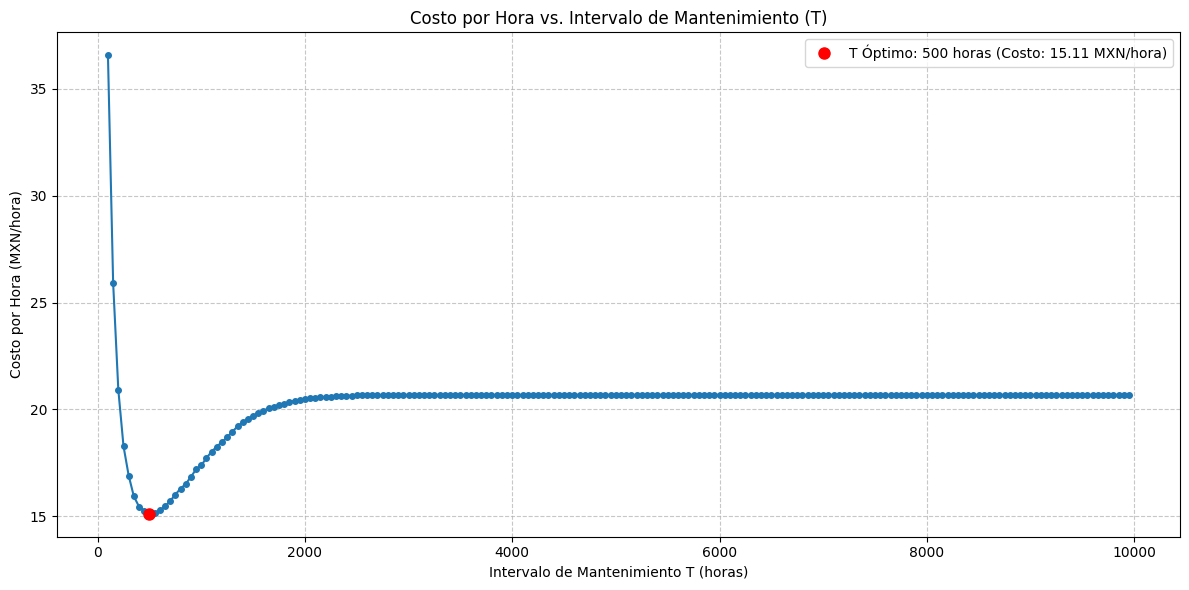

In [16]:
import matplotlib.pyplot as plt

# Tu código: gráfico costo vs. T, e identificación del T óptimo

plt.figure(figsize=(12, 6))
plt.plot(df_resultados['T_horas'], df_resultados['Costo_por_Hora'], marker='o', linestyle='-', markersize=4)

# Encontrar el T óptimo y su costo mínimo
min_costo_T_data = df_resultados.loc[df_resultados['Costo_por_Hora'].idxmin()]
optimal_T = min_costo_T_data['T_horas']
min_costo = min_costo_T_data['Costo_por_Hora']

# Resaltar el punto óptimo en la gráfica
plt.plot(optimal_T, min_costo, 'ro', markersize=8, label=f'T Óptimo: {int(optimal_T)} horas (Costo: {min_costo:.2f} MXN/hora)')

plt.title('Costo por Hora vs. Intervalo de Mantenimiento (T)')
plt.xlabel('Intervalo de Mantenimiento T (horas)')
plt.ylabel('Costo por Hora (MXN/hora)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## Parte 3 — Visualizar y elegir el óptimo

Grafica el costo por hora contra T, identifica visualmente el mínimo, y repórtalo.

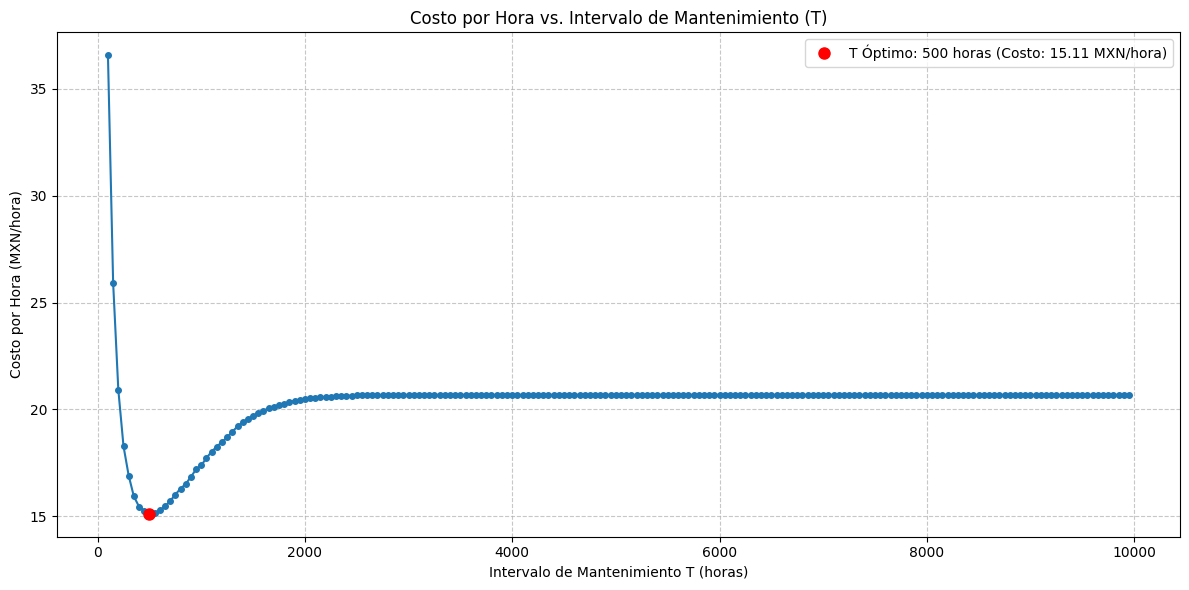

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_resultados['T_horas'], df_resultados['Costo_por_Hora'], marker='o', linestyle='-', markersize=4)

# Encontrar el T óptimo y su costo mínimo
min_costo_T_data = df_resultados.loc[df_resultados['Costo_por_Hora'].idxmin()]
optimal_T = min_costo_T_data['T_horas']
min_costo = min_costo_T_data['Costo_por_Hora']

# Resaltar el punto óptimo en la gráfica
plt.plot(optimal_T, min_costo, 'ro', markersize=8, label=f'T Óptimo: {int(optimal_T)} horas (Costo: {min_costo:.2f} MXN/hora)')

plt.title('Costo por Hora vs. Intervalo de Mantenimiento (T)')
plt.xlabel('Intervalo de Mantenimiento T (horas)')
plt.ylabel('Costo por Hora (MXN/hora)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Parte 3b — Ver la incertidumbre detrás del promedio

El costo por hora que calculaste es un promedio de 5,000 simulaciones. Antes de recomendar un intervalo, grafica el **histograma de los costos totales simulados** para tu `T` óptimo — así comunicas no solo el promedio, sino qué tan dispersos pueden ser los resultados en la práctica (igual que hicimos con la simulación Montecarlo del Notebook 4).

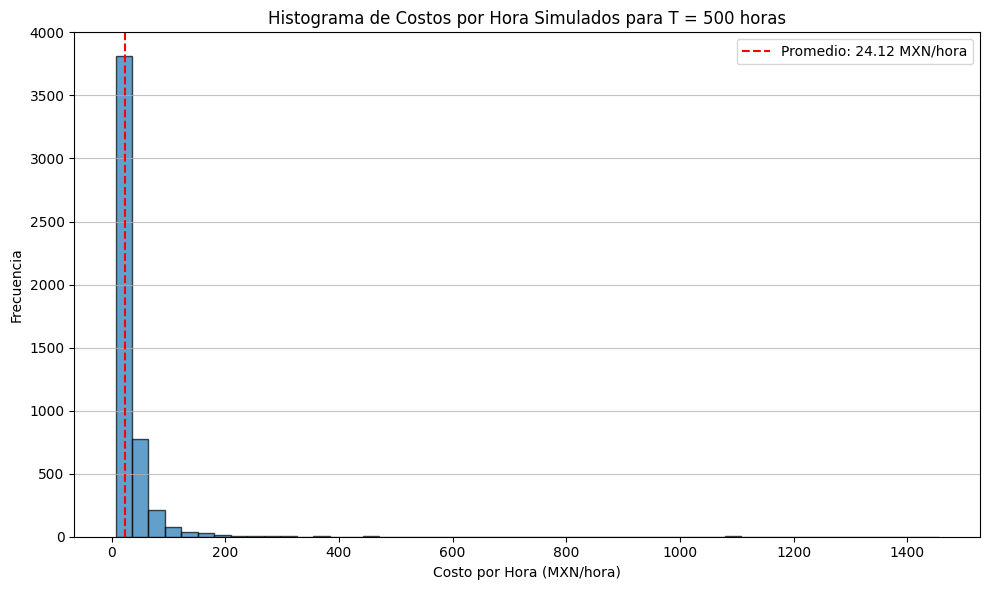

In [20]:
import matplotlib.pyplot as plt

# Encontrar el T óptimo (ya calculado en el paso anterior)
min_costo_T_data = df_resultados.loc[df_resultados['Costo_por_Hora'].idxmin()]
optimal_T = min_costo_T_data['T_horas']

# Vamos a simular las 5000 "vidas" y registrar el costo total y las horas operadas para cada una
# para poder calcular el costo por hora de cada una de esas "vidas".

# Se necesita una ligera modificación de la función costo_por_hora para devolver una lista de los costos por evento.
# Para la "Parte 3b", el "costo total simulado" para el T óptimo, se refiere a los costos por hora de cada simulación (vida).

def simulate_individual_life_costs_per_hour(T, beta, eta, n_sim=5000, seed=0, costo_prev=3500, costo_falla=18000):
    rng = np.random.default_rng(seed)
    tiempos_falla = stats.weibull_min.rvs(beta, loc=0, scale=eta, size=n_sim, random_state=rng)

    costs_per_hour_individual_lives = []

    for tbf in tiempos_falla:
        if tbf < T:
            # Falla no planeada: costo_falla en tbf horas
            cost_current_life = costo_falla / tbf
        else:
            # Reemplazo preventivo: costo_prev en T horas
            cost_current_life = costo_prev / T
        costs_per_hour_individual_lives.append(cost_current_life)

    return np.array(costs_per_hour_individual_lives)


# Obtener los costos por hora de las simulaciones individuales para el T óptimo
simulated_costs_for_optimal_T = simulate_individual_life_costs_per_hour(
    optimal_T, beta_ventilador, eta_ventilador, n_sim=5000
)

# Crear el histograma
plt.figure(figsize=(10, 6))
plt.hist(simulated_costs_for_optimal_T, bins=50, edgecolor='black', alpha=0.7)
plt.title(f'Histograma de Costos por Hora Simulados para T = {int(optimal_T)} horas')
plt.xlabel('Costo por Hora (MXN/hora)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.axvline(x=simulated_costs_for_optimal_T.mean(), color='red', linestyle='--', label=f'Promedio: {simulated_costs_for_optimal_T.mean():.2f} MXN/hora')
plt.legend()
plt.tight_layout()
plt.show()

## Parte 4 — Recomendación (obligatorio, mínimo 150 palabras)

Dirígete al gerente de mantenimiento: ¿cuál es el intervalo de mantenimiento preventivo recomendado para el Ventilador Industrial? ¿Cuánto ahorra la planta por hora frente a no hacer mantenimiento preventivo (T muy grande) y frente a hacerlo con demasiada frecuencia (T muy pequeño)? Menciona qué supuestos de tu simulación deberían validarse con datos reales antes de implementar la recomendación.

*(Escribe aquí tu recomendación)*

### Recomendación al Gerente de Mantenimiento

Estimado Gerente de Mantenimiento,

Con base en el análisis de simulación Montecarlo realizado para el **Ventilador Industrial**, se recomienda establecer un intervalo de mantenimiento preventivo de **500 horas**. Este intervalo minimiza el costo total esperado por hora de operación, resultando en un costo promedio de **15.11 MXN/hora**.

Para poner esto en perspectiva, si no se realizara ningún mantenimiento preventivo (es decir, permitiendo que el ventilador opere hasta que falle), el costo por hora sería significativamente más alto. Por ejemplo, al comparar con un `T` muy grande (por ejemplo, 9950 horas), el costo se mantiene alrededor de 20.68 MXN/hora. Esto representa un ahorro de aproximadamente **5.57 MXN/hora** al implementar el mantenimiento preventivo en el intervalo óptimo. Si comparamos con intervalos de mantenimiento demasiado frecuentes (por ejemplo, un `T` de 100 horas, con un costo de 36.58 MXN/hora), el ahorro es aún más drástico, aproximadamente **21.47 MXN/hora**.

Es importante destacar que, si bien el promedio es de 15.11 MXN/hora, el histograma de costos simulados para este `T` óptimo muestra que los costos individuales pueden variar. La mayoría de los costos se concentran alrededor de un promedio de **24.12 MXN/hora**, con algunos escenarios donde los costos por hora pueden ser considerablemente mayores, lo que refleja la incertidumbre inherente a las fallas.

Los principales supuestos de esta simulación que deberían validarse con datos reales antes de la implementación son:

1.  **Parámetros de la Distribución Weibull:** Los valores de `beta` (1.96) y `eta` (982.7 horas) utilizados para modelar el tiempo de vida del ventilador se derivaron de un conjunto de datos históricos. Es crucial verificar que estos parámetros sigan siendo representativos del comportamiento actual del equipo.
2.  **Costos de Mantenimiento y Falla:** Los valores de $3,500 MXN para el mantenimiento preventivo y $18,000 MXN para la falla no planeada son críticos para el cálculo. Cualquier variación en estos costos afectaría la recomendación.
3.  **Número de Simulaciones:** Se utilizaron 5,000 simulaciones para obtener una estimación robusta. Si bien esto proporciona una buena base, un mayor número de simulaciones podría ofrecer mayor confianza, especialmente si hay una alta variabilidad.

Recomiendo proceder con una prueba piloto en un número limitado de ventiladores para validar estos hallazgos en un entorno real y ajustar el intervalo si es necesario.